Question 2: 

2c. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=6)

a = 0.04
b = 0.16
K = 0.1

# Right jump probabilities
p1 = K * np.exp(a * 1)
p2 = K * np.exp(a * 2)
p3 = K * np.exp(a * 3)
p4 = K * np.exp(a * 4)

# Left jump probabilities
q2 = K * np.exp(b * (2 - 1))
q3 = K * np.exp(b * (3 - 1))
q4 = K * np.exp(b * (4 - 1))
q5 = K * np.exp(b * (5 - 1))

print("p1, p2, p3, p4 =", p1, p2, p3, p4)
print("q2, q3, q4, q5 =", q2, q3, q4, q5)

P = np.array([
    [1 - p1,      p1,          0.0,         0.0,         0.0],
    [q2,          1-p2-q2,     p2,          0.0,         0.0],
    [0.0,         q3,          1-p3-q3,     p3,          0.0],
    [0.0,         0.0,         q4,          1-p4-q4,     p4],
    [0.0,         0.0,         0.0,         q5,          1-q5]
], dtype=float)

def simulate_chain(P, n_steps=10**6, start_state=1, seed=12345):
    """
    Simulate a Markov chain with transition matrix P.

    Parameters

    P : ndarray
        Row-stochastic transition matrix.
    n_steps : int
        Number of time steps.
    start_state : int
        Initial state in {1,2,3,4,5}.
    seed : int
        RNG seed.

    Returns

    counts : ndarray
        Number of visits to each state.
    fractions : ndarray
        Fraction of time spent in each state.
    path : ndarray
        Simulated path (0-based state indices).
    """
    rng = np.random.default_rng(seed)
    n_states = P.shape[0]

    state = start_state - 1   # convert 1-based to 0-based
    counts = np.zeros(n_states, dtype=int)
    path = np.empty(n_steps, dtype=int)

    for t in range(n_steps):
        counts[state] += 1
        path[t] = state
        state = rng.choice(n_states, p=P[state])

    fractions = counts / n_steps
    return counts, fractions, path

n_steps = 10**6
counts, empirical_pi, path = simulate_chain(P, n_steps=n_steps, start_state=1, seed=12345)

print("Counts:")
print(counts)

print("\nEmpirical fractions:")
for i, val in enumerate(empirical_pi, start=1):
    print(f"State {i}: {val:.6f}")




p1, p2, p3, p4 = 0.10408107741923883 0.10832870676749587 0.11274968515793758 0.11735108709918103
q2, q3, q4, q5 = 0.11735108709918103 0.13771277643359572 0.16160744021928936 0.18964808793049515
Counts:
[295057 262641 207919 144677  89706]

Empirical fractions:
State 1: 0.295057
State 2: 0.262641
State 3: 0.207919
State 4: 0.144677
State 5: 0.089706


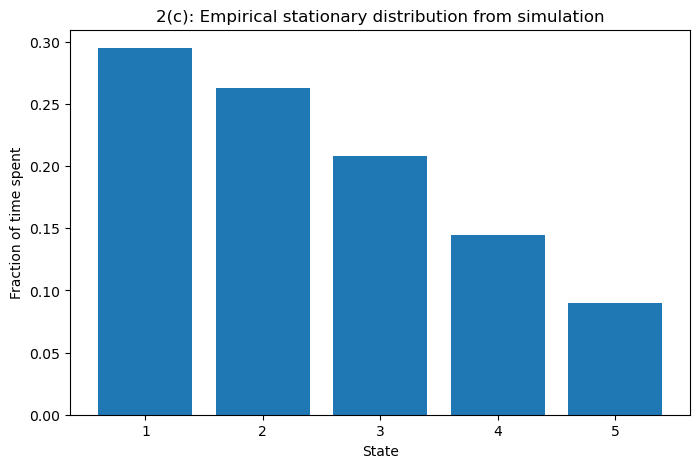

In [26]:
states = np.arange(1, 6)

plt.figure(figsize=(8,5))
plt.bar(states, empirical_pi)
plt.xlabel("State")
plt.ylabel("Fraction of time spent")
plt.title("2(c): Empirical stationary distribution from simulation")
plt.xticks(states)
plt.show()


2d. 

In [27]:
weights_a = np.array([
    np.exp((a-b) * (i*(i-1)/2)) for i in range(1, 6)
], dtype=float)

pi_theory_a = weights_a / weights_a.sum()

print("Theoretical pi from 2(a):")
for i, val in enumerate(pi_theory_a, start=1):
    print(f"State {i}: {val:.6f}")


Theoretical pi from 2(a):
State 1: 0.296512
State 2: 0.262983
State 3: 0.206869
State 4: 0.144328
State 5: 0.089308


In [29]:
eigvals, eigvecs = np.linalg.eig(P.T)

# Find the eigenvector corresponding to eigenvalue 1
idx = np.argmin(np.abs(eigvals - 1))
vec = np.real(eigvecs[:, idx])

# Make sure sign is positive
vec = np.abs(vec)

pi_theory_b = vec / vec.sum()

print("Theoretical pi from 2(b):")
for i, val in enumerate(pi_theory_b, start=1):
    print(f"State {i}: {val:.6f}")



Theoretical pi from 2(b):
State 1: 0.296512
State 2: 0.262983
State 3: 0.206869
State 4: 0.144328
State 5: 0.089308


In [30]:
eigvals, eigvecs = np.linalg.eig(P.T)

# Find the eigenvector corresponding to eigenvalue 1
idx = np.argmin(np.abs(eigvals - 1))
vec = np.real(eigvecs[:, idx])

# Make sure sign is positive
vec = np.abs(vec)

pi_theory_b = vec / vec.sum()

print("Theoretical pi from 2(b):")
for i, val in enumerate(pi_theory_b, start=1):
    print(f"State {i}: {val:.6f}")


Theoretical pi from 2(b):
State 1: 0.296512
State 2: 0.262983
State 3: 0.206869
State 4: 0.144328
State 5: 0.089308


In [31]:
print("State   Empirical      Theory (a)     Theory (b)")
for i in range(5):
    print(f"{i+1:>2}      {empirical_pi[i]:.6f}      {pi_theory_a[i]:.6f}      {pi_theory_b[i]:.6f}")


State   Empirical      Theory (a)     Theory (b)
 1      0.295057      0.296512      0.296512
 2      0.262641      0.262983      0.262983
 3      0.207919      0.206869      0.206869
 4      0.144677      0.144328      0.144328
 5      0.089706      0.089308      0.089308


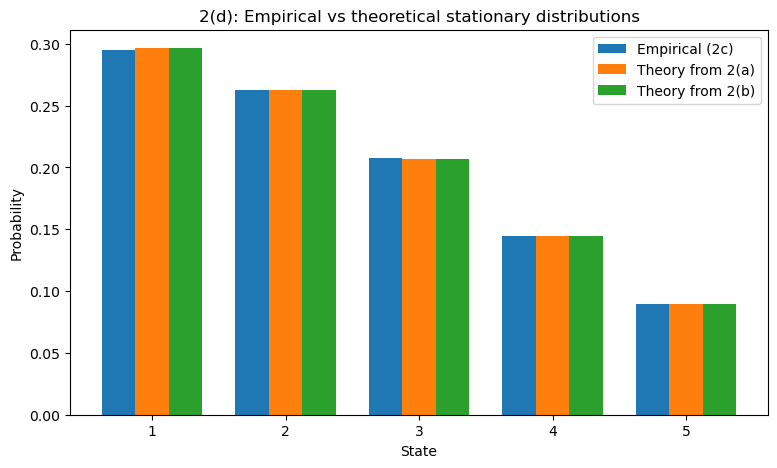

In [32]:
states = np.arange(1, 6)
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(states - width, empirical_pi, width=width, label='Empirical (2c)')
plt.bar(states,         pi_theory_a, width=width, label='Theory from 2(a)')
plt.bar(states + width, pi_theory_b, width=width, label='Theory from 2(b)')

plt.xlabel("State")
plt.ylabel("Probability")
plt.title("2(d): Empirical vs theoretical stationary distributions")
plt.xticks(states)
plt.legend()
plt.show()


Problem 3: 

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import math

np.set_printoptions(suppress=True, precision=6)

a = sp.symbols('a', real=True)

P = sp.Matrix([
    [1-a, a,   0],
    [a,   0, 1-a],
    [0, 1-a,   a]
])

P

Matrix([
[1 - a,     a,     0],
[    a,     0, 1 - a],
[    0, 1 - a,     a]])

3a. Find the stationary distribution π.

In [3]:
x, y, z = sp.symbols('x y z', real=True)
pi = sp.Matrix([[x, y, z]])  # row vector

eq_mat = sp.expand(pi * P - pi)

eqs = [
    sp.Eq(eq_mat[0, 0], 0),
    sp.Eq(eq_mat[0, 1], 0),
    sp.Eq(eq_mat[0, 2], 0),
    sp.Eq(x + y + z, 1)
]

sol_pi = sp.solve(eqs, [x, y, z], dict=True)[0]
sol_pi


{x: 1/3, y: 1/3, z: 1/3}

In [4]:
pi_stationary = sp.Matrix([sp.Rational(1, 3), sp.Rational(1, 3), sp.Rational(1, 3)])
pi_stationary


Matrix([
[1/3],
[1/3],
[1/3]])

Find the eigenvectors and eigenvalues of the transpose of the probability transition matrix
A = pT . You are not only allowed, but encouraged, to use software to find the eigenvectors and
eigenvalues of p as a function of a

In [5]:
A = P.T
A


Matrix([
[1 - a,     a,     0],
[    a,     0, 1 - a],
[    0, 1 - a,     a]])

In [6]:
charpoly = sp.factor(A.charpoly().as_expr())
charpoly


-(lambda - 1)*(3*a**2 - 3*a - lambda**2 + 1)

In [7]:
eigs = A.eigenvects()
eigs


[(1,
  1,
  [Matrix([
   [1],
   [1],
   [1]])]),
 (-sqrt(3*a**2 - 3*a + 1),
  1,
  [Matrix([
   [(1 - 2*a)/(a - 1) - sqrt(3*a**2 - 3*a + 1)/(a - 1)],
   [        a/(a - 1) + sqrt(3*a**2 - 3*a + 1)/(a - 1)],
   [                                                 1]])]),
 (sqrt(3*a**2 - 3*a + 1),
  1,
  [Matrix([
   [(1 - 2*a)/(a - 1) + sqrt(3*a**2 - 3*a + 1)/(a - 1)],
   [        a/(a - 1) - sqrt(3*a**2 - 3*a + 1)/(a - 1)],
   [                                                 1]])])]

3c. Set a = 0.99. Suppose that X0 = 1. By decomposing qT 0 into eigenvectors of A and using qT
n+1 = AqT n , find an expression for qn and show that it converges exponentially to π. For this part, you can work numerically and use software to do any required calculation.


In [8]:
a_val = 0.99

A_num = np.array([
    [1-a_val, a_val,   0.0],
    [a_val,   0.0, 1-a_val],
    [0.0, 1-a_val, a_val]
], dtype=float)

A_num


array([[0.01, 0.99, 0.  ],
       [0.99, 0.  , 0.01],
       [0.  , 0.01, 0.99]])

In [9]:
eigvals, eigvecs = np.linalg.eig(A_num)
eigvals, eigvecs


(array([-0.985038,  1.      ,  0.985038]),
 array([[ 0.705305,  0.57735 , -0.411353],
        [-0.708895,  0.57735 , -0.405136],
        [ 0.003589,  0.57735 ,  0.816489]]))

In [ ]:
q0 = np.array([1.0, 0.0, 0.0])  

coeffs = np.linalg.solve(eigvecs, q0)
coeffs


array([ 0.705305,  0.57735 , -0.411353])

In [12]:
def qn_from_eigendecomp(n):
    Dn = np.diag(eigvals**n)
    return eigvecs @ Dn @ coeffs

for n in range(5):
    qn = np.real_if_close(qn_from_eigendecomp(n))
    print(f"n={n}: {qn}, sum={qn.sum()}")



n=0: [ 1. -0.  0.], sum=1.0
n=1: [ 0.01  0.99 -0.  ], sum=0.9999999999999997
n=2: [0.9802 0.0099 0.0099], sum=0.9999999999999994
n=3: [0.019603 0.970497 0.0099  ], sum=0.9999999999999991
n=4: [0.960988 0.019506 0.019506], sum=0.9999999999999984


In [13]:
r_val = math.sqrt(3*a_val*a_val - 3*a_val + 1)
r_val


0.9850380703302791

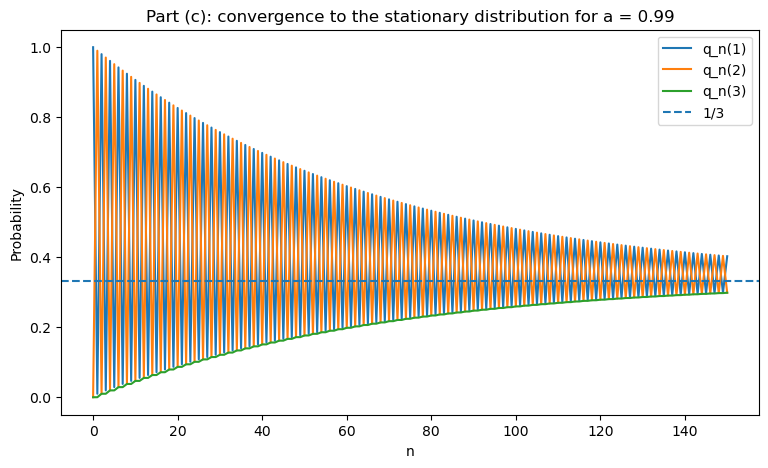

In [14]:
N_plot = 150
traj = np.array([np.real_if_close(qn_from_eigendecomp(n)) for n in range(N_plot + 1)])

plt.figure(figsize=(9,5))
plt.plot(traj[:, 0], label='q_n(1)')
plt.plot(traj[:, 1], label='q_n(2)')
plt.plot(traj[:, 2], label='q_n(3)')
plt.axhline(1/3, linestyle='--', label='1/3')
plt.xlabel('n')
plt.ylabel('Probability')
plt.title('Part (c): convergence to the stationary distribution for a = 0.99')
plt.legend()
plt.show()


For what value of a is the convergence to the stationary distribution faster? Find the value
using your expression in (c) and also give an intuitive explanation.

In [15]:
rho_sq = 3*a**2 - 3*a + 1
sp.diff(rho_sq, a)


6*a - 3

In [16]:
a_star = sp.solve(sp.Eq(sp.diff(rho_sq, a), 0), a)[0]
rho_star = sp.simplify(sp.sqrt(rho_sq.subs(a, a_star)))

a_star, rho_star


(1/2, 1/2)

3e. Run N = 100 versions of the Markov Chain with a = 0.99, all of them starting at state 1. At time n, calculate the fraction fn of the Chains that are in state 1. Plot fn and the theoretical expression you found for qn(1) as a function of n on the same plot, for n ranging from 0 to a few hundred. Repeat for N = 1000 and N = 10, 000. If they are not agreeing reasonably well, something is wrong!

In [17]:
P_num = np.array([
    [1-a_val, a_val,   0.0],
    [a_val,   0.0, 1-a_val],
    [0.0, 1-a_val, a_val]
], dtype=float)

P_num


array([[0.01, 0.99, 0.  ],
       [0.99, 0.  , 0.01],
       [0.  , 0.01, 0.99]])

In [ ]:
def theoretical_qn_state1(max_n, a=0.99):
    P = np.array([
        [1-a, a,   0.0],
        [a,   0.0, 1-a],
        [0.0, 1-a, a]
    ], dtype=float)

    q = np.array([1.0, 0.0, 0.0])  
    vals = [q[0]]

    for _ in range(max_n):
        q = q @ P
        vals.append(q[0])

    return np.array(vals)


In [19]:
def simulate_fraction_in_state1(num_chains, max_n, a=0.99, seed=12345):
    rng = np.random.default_rng(seed)

    # states 0,1,2 represent states 1,2,3
    states = np.zeros(num_chains, dtype=int)  # all start in state 1
    fractions = np.empty(max_n + 1)
    fractions[0] = np.mean(states == 0)

    for n in range(1, max_n + 1):
        prev = states.copy()
        u = rng.random(num_chains)

        # previous state 1
        mask = (prev == 0)
        states[mask] = np.where(u[mask] < a, 1, 0)

        # previous state 2
        mask = (prev == 1)
        states[mask] = np.where(u[mask] < a, 0, 2)

        # previous state 3
        mask = (prev == 2)
        states[mask] = np.where(u[mask] < (1-a), 1, 2)

        fractions[n] = np.mean(states == 0)

    return fractions


In [20]:
max_n = 300
theory_state1 = theoretical_qn_state1(max_n, a=0.99)

Ns = [100, 1000, 10000]
sim_results = {
    N: simulate_fraction_in_state1(N, max_n, a=0.99, seed=12345 + N)
    for N in Ns
}

for N in Ns:
    print(f"N={N}, first 10 values:")
    print(sim_results[N][:10])
    print()


N=100, first 10 values:
[1.   0.02 0.97 0.04 0.94 0.06 0.91 0.09 0.88 0.09]

N=1000, first 10 values:
[1.    0.008 0.976 0.016 0.959 0.033 0.937 0.044 0.915 0.05 ]

N=10000, first 10 values:
[1.     0.0099 0.9789 0.0182 0.9597 0.0283 0.9396 0.037  0.9228 0.0464]



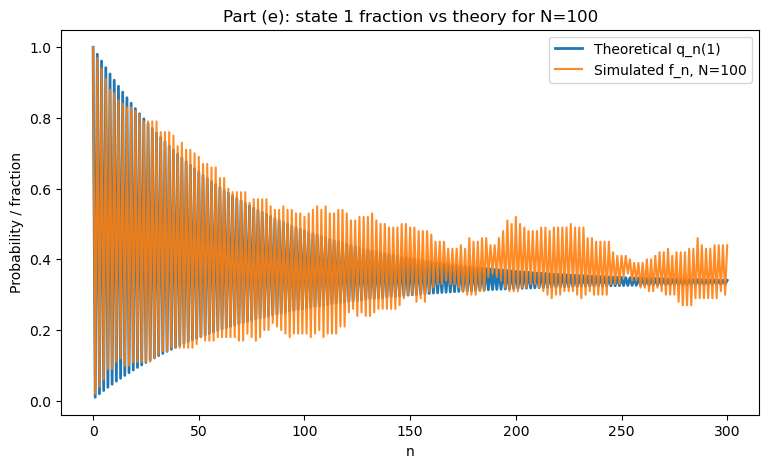

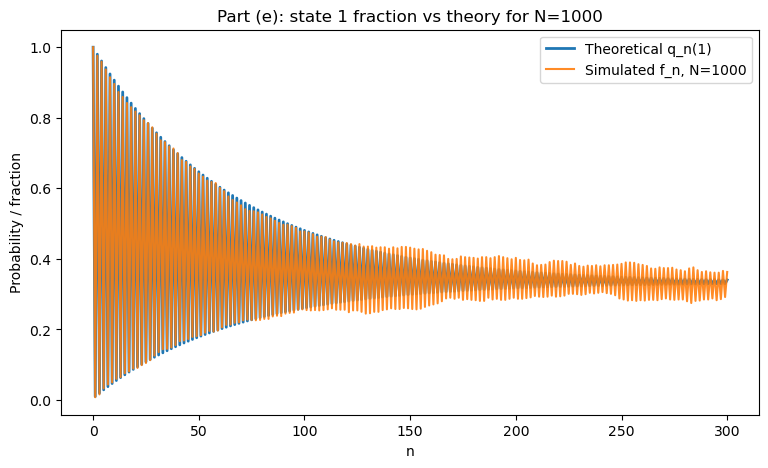

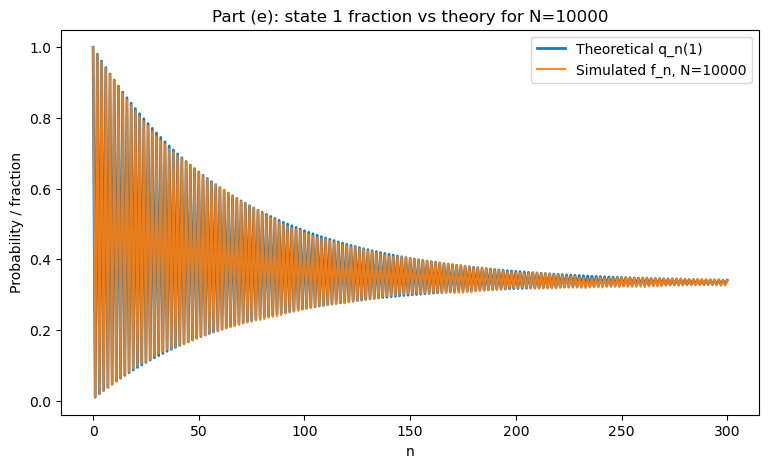

In [21]:
for N in Ns:
    plt.figure(figsize=(9,5))
    plt.plot(theory_state1, label='Theoretical q_n(1)', linewidth=2)
    plt.plot(sim_results[N], label=f'Simulated f_n, N={N}', alpha=0.9)
    plt.xlabel('n')
    plt.ylabel('Probability / fraction')
    plt.title(f'Part (e): state 1 fraction vs theory for N={N}')
    plt.legend()
    plt.show()


In [22]:
print("Part (a):")
print("pi = (1/3, 1/3, 1/3)")

print("\nPart (b):")
print("Eigenvalues of A = P^T are:")
print("1, sqrt(3a^2 - 3a + 1), -sqrt(3a^2 - 3a + 1)")

print("\nPart (c):")
print(f"For a = 0.99, convergence rate r = {r_val:.6f}")

print("\nPart (d):")
print(f"Fastest convergence occurs at a = {a_star}")
print(f"Minimum second-largest eigenvalue magnitude = {rho_star}")

print("\nPart (e):")
print("Simulation code compares empirical fraction in state 1 against theoretical q_n(1).")


Part (a):
pi = (1/3, 1/3, 1/3)

Part (b):
Eigenvalues of A = P^T are:
1, sqrt(3a^2 - 3a + 1), -sqrt(3a^2 - 3a + 1)

Part (c):
For a = 0.99, convergence rate r = 0.985038

Part (d):
Fastest convergence occurs at a = 1/2
Minimum second-largest eigenvalue magnitude = 1/2

Part (e):
Simulation code compares empirical fraction in state 1 against theoretical q_n(1).
